## C-Drama RAG: Data Exploration

**Goals:**
- Understand the shape of the data
- Find nulls, weird values 
- Decide what needs cleaning before inserting into supabase

Important fields for embedding: **synopsis** and **tags**

### Setup & Data Loading
data saved as NDJSON - newline-delimited JSON, each line is one drama

In [1]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/raw/dramas.jsonl")

df = pd.read_json(DATA_PATH, lines=True)

print(f"Shape: {df.shape}")  # (rows, cols) 

Shape: (2710, 11)


### Check quality of data, identify scraping errors before cleaning
focus is on dramas with:
- rating of 7.5 and higher 
- 10 or more episodes (to filter out specials and extras)
- 500 or more watchers (to get good dramas from the recommender)

### 1. Schema and Data Types

In [2]:
# df.dtypes — types per column
print(df.dtypes)
print()

# df.info() — types + non-null counts + memory usage
df.info()

mdl_id            int64
mdl_url             str
title               str
native_title        str
synopsis            str
episodes          int64
year              int64
genres           object
tags             object
mdl_score       float64
watchers          int64
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 2710 entries, 0 to 2709
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mdl_id        2710 non-null   int64  
 1   mdl_url       2710 non-null   str    
 2   title         2710 non-null   str    
 3   native_title  2709 non-null   str    
 4   synopsis      2710 non-null   str    
 5   episodes      2710 non-null   int64  
 6   year          2710 non-null   int64  
 7   genres        2710 non-null   object 
 8   tags          2710 non-null   object 
 9   mdl_score     2628 non-null   float64
 10  watchers      2710 non-null   int64  
dtypes: float64(1), int64(4), object(2), str(4)
memory usage: 233.

**Findings — Schema:**
- `genres` and `tags` are `object` dtype — expected, since pandas uses `object` for columns containing Python lists.
- `native_title` has 1 null — likely a drama with no known native title on MDL.
- `mdl_score` has 82 null values — minor; most likely not popular dramas

In [3]:
# peek at the first 3 rows
df.head(3)

,mdl_id,mdl_url,title,native_title,synopsis,episodes,year,genres,tags,mdl_score,watchers
0,760409,https://mydramalist.com/760409-zhu-yu,Pursuit of Jade,逐玉,"It follows Fan Chang Yu, a butcher’s daughter,...",40,2026,"[Historical, Mystery, Romance, War]","[Fake To Real Lovers, Physically Strong Female...",9.1,40464
1,53505,https://mydramalist.com/53505-the-untamed-spec...,The Untamed Special Edition,陈情令特別剪辑版,A 20-episode cut of The Untamed made for bette...,20,2019,"[Mystery, Wuxia, Fantasy]","[Bromance, Smart Male Lead, Censored Adaptatio...",9.0,39873
2,9025,https://mydramalist.com/9025-nirvana-in-fire,Nirvana in Fire,琅琊榜,"In sixth-century China, the Emperor of Great L...",54,2015,"[Military, Historical, Drama, Political]","[Power Struggle, Smart Male Lead, Scheme, Deat...",9.0,60460


In [4]:
df.describe()

,mdl_id,episodes,year,mdl_score,watchers
count,2710.000000,2710.000000,2710.000000,2628.000000,2710.000000
mean,304186.692251,34.040959,2018.560517,7.946918,5308.238376
std,341654.935267,19.424561,6.198798,0.546632,11032.207075
min,402.000000,1.000000,1983.000000,7.100000,2.000000
25%,29584.750000,24.000000,2016.000000,7.600000,106.250000
50%,59643.000000,32.000000,2020.000000,7.800000,859.000000
75%,720863.500000,40.000000,2023.000000,8.000000,5599.750000
max,807500.000000,367.000000,2026.000000,10.000000,150655.000000


**Findings — Descriptive Stats:**
- `mdl_score` ranges from 7.1 to 10.0 with a mean of ~7.95 and low variance (std ~0.55) — requirement was dramas with score 7.5 and higher, so most likely scraper bug
- `episodes` max is 367 — plausible for long-running historical dramas; most dramas fall between 24–40 episodes
- `watchers` is heavily right-skewed: median is 859 but mean is 5,308, and max is 150,655. The distribution is dominated by a small number of breakout hits.
- `year` ranges 1983–2026, with a median of 2020 — the dataset is mostly modern dramas.

### 2. Null Values

In [5]:
# isna() returns a boolean DataFrame (True where value is missing)
# .sum() counts True values per column
print("Null counts per column:")
print(df.isna().sum())

Null counts per column:
mdl_id           0
mdl_url          0
title            0
native_title     1
synopsis         0
episodes         0
year             0
genres           0
tags             0
mdl_score       82
watchers         0
dtype: int64


In [6]:
empty_synopsis = df[
    df["synopsis"].isna() | (df["synopsis"].str.strip() == "")
]
print(f"Dramas with missing or empty synopsis: {len(empty_synopsis)}")

Dramas with missing or empty synopsis: 0


In [7]:
empty_genres = df[df["genres"].apply(len) == 0]
empty_tags = df[df["tags"].apply(len) == 0]

print(f"Dramas with empty genres: {len(empty_genres)}")
print(f"Dramas with empty tags: {len(empty_tags)}")

Dramas with empty genres: 10
Dramas with empty tags: 257


**Findings — Empty Lists:**
- `genres`: 10 dramas with no genres; worth inspecting to see if they're the same low-quality dramas filtered out by other criteria anyway.
- `tags`: 257 dramas with no tags; will most likely be also filtered out by other criteria 
- worth checking out after cleaning as both are important for search/embedding

### 3. Scores

In [9]:
# Minimum required score is 7.5

too_low_scores = df[df["mdl_score"] < 7.5]
print(f"Dramas with score < 7.5: {len(too_low_scores)}")

good_range = df[df["mdl_score"].between(7.5, 10.0)]
print(f"Dramas with score 7.5–10.0: {len(good_range)}")

Dramas with score < 7.5: 17
Dramas with score 7.5–10.0: 2611


**Findings — Score Range:**
- Only 17 dramas fall below the 7.5 threshold — a very small amount of low-quality data.
- 2,611 dramas (~96%) fall in the valid 7.5–10.0 range, meaning the score filter has minimal impact on dataset size.

### 4. Watchers and Episodes

In [10]:
low_watchers = df[df["watchers"] < 500]
short_dramas = df[df["episodes"] < 10]

print(f"Dramas with < 500 watchers: {len(low_watchers)}")
print(f"Dramas with < 10 episodes: {len(short_dramas)}")

Dramas with < 500 watchers: 1181
Dramas with < 10 episodes: 131


**Findings — Watchers & Episodes:**
- 1,181 dramas (~44%) have fewer than 500 watchers — this is the most impactful filter, cutting the dataset nearly in half. These are obscure dramas that likely have sparse/unreliable metadata.
- 131 dramas (~5%) have fewer than 10 episodes — mostly specials, compilations, or short-form content that wouldn't make sense to recommend as a full drama.
- There is likely overlap between these two groups (obscure dramas tend to also be short-form)

### 5. Duplicates
to make sure there isn't same drama scraped twice

In [11]:
print(f"Duplicate mdl_ids: {df['mdl_id'].duplicated().sum()}")  
print(f"Total unique dramas: {df['mdl_id'].nunique()}")   

Duplicate mdl_ids: 0
Total unique dramas: 2710


**Findings — Duplicates:**
- No duplicate `mdl_id` values — the scraper did not double-scrape any drama. The dataset is clean on this dimension, no deduplication step needed.

### 6. Synopsis Quality Check

In [12]:
# quick look at synopsis
df["synopsis"][1]

'A 20-episode cut of The Untamed made for better integration and comprehension of the series. This special edition focuses more on Lan Wangji/Lan Zhan and Wei Wuxian/Wei Ying.Edit TranslationEnglishРусскийFrançaismagyar / magyar nyelv'

In [13]:
lengths = df["synopsis"].str.len()  

print(f"Avg length: {lengths.mean():.0f}")
print(f"Min length: {lengths.min()}")
print(f"Max length: {lengths.max()}")

Avg length: 592
Min length: 50
Max length: 5749


**Findings — Synopsis Lengths:**
- Average synopsis is 592 characters — a reasonable length for embedding.
- Minimum is 50 characters — very short, but there are no empty synopses. After stripping the `Edit Translation` junk suffix (see next cell), some of these very short ones may drop below a useful length threshold. Check distribution of post-clean lengths in notebook 02.

In [14]:
# Check for 'Edit Translation' junk in synopses
junk_mask = df["synopsis"].str.contains("Edit Translation", na=False)
# na=False means: treat NaN as False (not a match)
print(f"Synopses with 'Edit Translation' junk: {junk_mask.sum()}")

Synopses with 'Edit Translation' junk: 2710


**Findings — Synopsis Junk:**
- `Edit Translation` suffix is present in **all 2,702 synopses** (100%) — this is a consistent scraping artifact from MDL's translation toggle UI being included in the scraped text.
- Cleaning strategy: strip everything from `"Edit Translation"` onward using `str.split("Edit Translation")[0].strip()`.
- The junk also includes language names (`English`, `Русский`, `Français`, etc.) appended after the translation links — all of this will be removed by the same split.

### 7. Genres & Tags

In [15]:
from collections import Counter

all_genres = [g for genres in df["genres"] for g in genres]
all_tags = [t for tags in df["tags"] for t in tags]

genre_counts = Counter(all_genres)
tag_counts = Counter(all_tags)

print(f"Unique genres: {len(genre_counts)}")
print(f"Unique tags:   {len(tag_counts)}")
print()

print("Top 15 genres:")
for g, n in genre_counts.most_common(15):
    print(f"  {g}: {n}")

print()
print("Top 20 tags:")
for t, n in tag_counts.most_common(20):
    print(f"  {t}: {n}")

Unique genres: 32
Unique tags:   1979

Top 15 genres:
  Romance: 1569
  Drama: 1065
  Historical: 786
  Comedy: 633
  Mystery: 455
  Fantasy: 445
  Life: 325
  Youth: 314
  Thriller: 309
  Wuxia: 285
  Action: 216
  Family: 169
  War: 144
  Business: 138
  Crime: 138

Top 20 tags:
  Web Series: 481
  Historical Fiction: 375
  Adapted From A Novel: 371
  Short Length Series: 358
  Investigation: 324
  Friendship: 305
  Suspense: 211
  Chinese Republican Era: 208
  Martial Arts: 184
  Smart Male Lead: 176
  Emotionally Strong Female Lead: 169
  Hidden Identity: 162
  Death: 161
  School Setting: 155
  Adventure: 150
  Smart Female Lead: 147
  Multiple Couples: 146
  Action: 145
  Adapted From A Web Novel: 145
  Age Gap [Real Life]: 137


**Findings — Genres & Tags:**
- 1,979 unique tags — a very long tail. The top tags (Web Series, Historical Fiction, Adapted From A Novel) are broad and common. 
- Tags like Web Series, Adapted From a Novel will be removed before creating embeddings as these are not relevant for similarity search.
- `Romance` (1,569) and `Drama` (1,065) dominate genres — expected for C-dramas. `Historical` (786) is the third most common, reflecting the genre's popularity in the dataset.

### 8. Visualizations
Key distributions at a glance. Red dashed lines show the quality filter thresholds.
Note: genres/tags plots require the `Counter` objects from section 7.

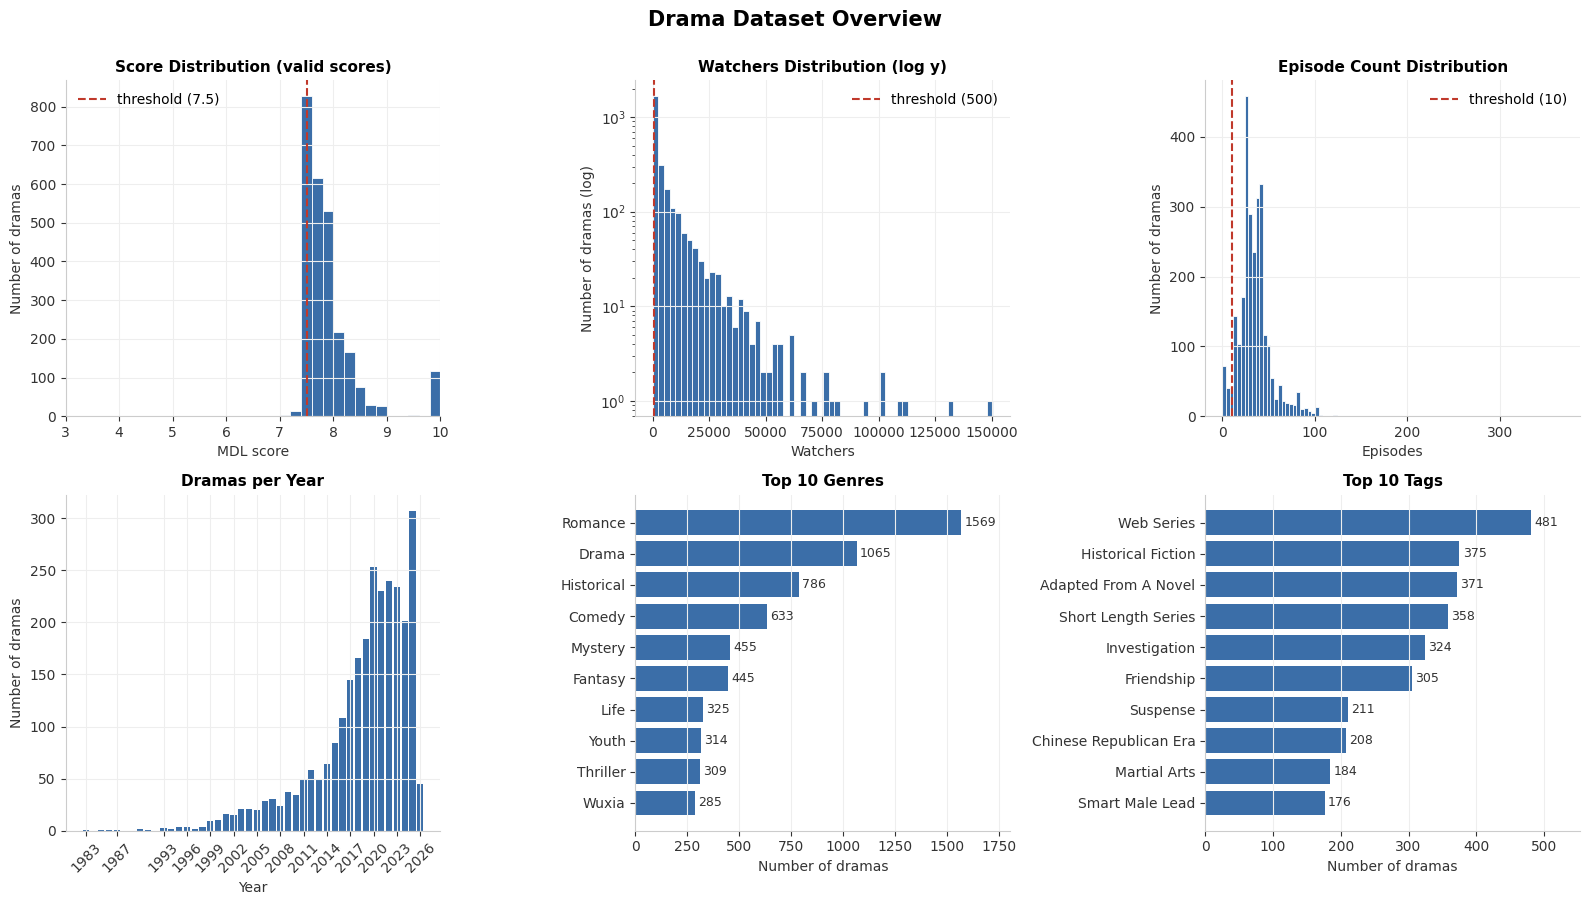

In [16]:
import matplotlib.pyplot as plt
import numpy as np

PRIMARY = "#3b6ea8"
ACCENT = "#c0392b"
TEXT = "#333333"

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.labelcolor": TEXT,
    "axes.edgecolor": "#cccccc",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "axes.grid": True,
    "grid.color": "#eeeeee",
    "grid.linestyle": "-",
    "grid.linewidth": 0.8,
})

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Drama Dataset Overview", fontsize=15, fontweight="bold", y=1.00)

# 1. Score distribution (valid range only)
valid_scores = df.loc[df["mdl_score"].between(0, 10), "mdl_score"]
ax = axes[0, 0]
ax.hist(valid_scores, bins=np.arange(3, 10.1, 0.2),
        color=PRIMARY, edgecolor="white", linewidth=0.6)
ax.axvline(7.5, color=ACCENT, linestyle="--", linewidth=1.5, label="threshold (7.5)")
ax.set_title("Score Distribution (valid scores)")
ax.set_xlabel("MDL score")
ax.set_ylabel("Number of dramas")
ax.set_xlim(3, 10)
ax.legend(frameon=False)

# 2. Watchers — log y-axis, heavily right-skewed
ax = axes[0, 1]
ax.hist(df["watchers"], bins=60, color=PRIMARY, edgecolor="white", linewidth=0.6)
ax.set_yscale("log")
ax.axvline(500, color=ACCENT, linestyle="--", linewidth=1.5, label="threshold (500)")
ax.set_title("Watchers Distribution (log y)")
ax.set_xlabel("Watchers")
ax.set_ylabel("Number of dramas (log)")
ax.legend(frameon=False)

# 3. Episodes
ax = axes[0, 2]
ax.hist(df["episodes"], bins=np.arange(0, df["episodes"].max() + 5, 4),
        color=PRIMARY, edgecolor="white", linewidth=0.6)
ax.axvline(10, color=ACCENT, linestyle="--", linewidth=1.5, label="threshold (10)")
ax.set_title("Episode Count Distribution")
ax.set_xlabel("Episodes")
ax.set_ylabel("Number of dramas")
ax.legend(frameon=False)

# 4. Dramas per year
ax = axes[1, 0]
year_counts = df["year"].dropna().astype(int).value_counts().sort_index()
ax.bar(year_counts.index, year_counts.values, color=PRIMARY, width=0.8)
ax.set_title("Dramas per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of dramas")
ax.set_xticks(year_counts.index[::3])
ax.tick_params(axis="x", rotation=45)

# 5. Top 10 genres
ax = axes[1, 1]
top_genres = genre_counts.most_common(10)
g_labels, g_vals = zip(*top_genres)
bars = ax.barh(g_labels[::-1], g_vals[::-1], color=PRIMARY)
ax.set_title("Top 10 Genres")
ax.set_xlabel("Number of dramas")
ax.set_xlim(0, max(g_vals) * 1.15)
ax.grid(axis="y", visible=False)
for bar in bars:
    w = bar.get_width()
    ax.text(w + max(g_vals) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{int(w)}", va="center", fontsize=9, color=TEXT)

# 6. Top 10 tags
ax = axes[1, 2]
top_tags = tag_counts.most_common(10)
t_labels, t_vals = zip(*top_tags)
bars = ax.barh(t_labels[::-1], t_vals[::-1], color=PRIMARY)
ax.set_title("Top 10 Tags")
ax.set_xlabel("Number of dramas")
ax.set_xlim(0, max(t_vals) * 1.15)
ax.grid(axis="y", visible=False)
for bar in bars:
    w = bar.get_width()
    ax.text(w + max(t_vals) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{int(w)}", va="center", fontsize=9, color=TEXT)

plt.tight_layout()
plt.show()

### Summary

Total dramas: 2,710
- dtypes: all correctly inferred by pandas (except lists come as `object` dtype)
- No duplicate mdl_ids
- Scores: 17 below 7.5
- Watchers: 1,181 dramas with < 500 watchers
- Episodes: 131 dramas with < 10 episodes
- Synopsis: All contain 'Edit Translation' junk → needs cleaning

### Next Steps → notebook 02 (cleaning)
- Strip `Edit Translation...` suffix from all synopses
- Drop dramas where post-clean synopsis length < ~150 chars (check distribution first)
- Apply quality filters: score 7.5–10.0, episodes ≥ 10, watchers ≥ 500
- Count usable dramas after all cleaning